In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [11]:
#| echo: true
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

Creating a synthetic dataset.

In [12]:
#| echo: true
np.random.seed(42)
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X_inliers, X_outliers]

Instantiating and fitting the methods.

In [13]:
#| echo: true
iso_forest = IsolationForest(contamination=0.15, random_state=42)
y_pred_iso = iso_forest.fit_predict(X)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.15)
y_pred_lof = lof.fit_predict(X)

Plotting the results, where the red dots are outliers.

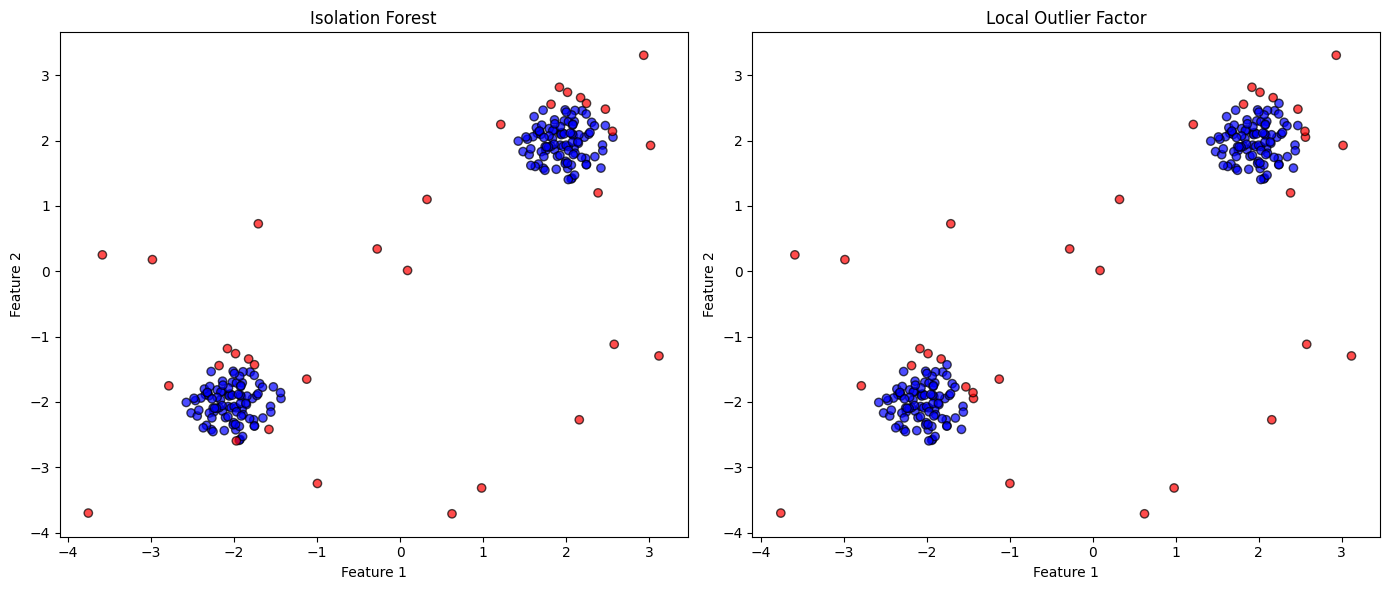

In [14]:
#| echo: true
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.title("Isolation Forest")
colors_iso = np.array(['red' if label == -1 else 'blue' for label in y_pred_iso])
plt.scatter(X[:, 0], X[:, 1], c=colors_iso, edgecolor='k', alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1, 2, 2)
plt.title("Local Outlier Factor")
colors_lof = np.array(['red' if label == -1 else 'blue' for label in y_pred_lof])
plt.scatter(X[:, 0], X[:, 1], c=colors_lof, edgecolor='k', alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()